# Разработка и исследование ML-модели для решения прикладной задачи  
Герасимов Данил, Захаров Илья ИД24-3

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.feature_selection import RFE
import pickle

## 1. Постановка задачи

Создать и обучить модель для определения спам-писем.

Т.к. все письма делятся на "спам" и "не спам", то понадобится классификация.

## 2. Данные

In [2]:
mail = pd.read_csv("spambase.csv")
mail.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [3]:
mail = mail.drop('word_freq_george', axis = 1)
mail = mail.drop('word_freq_650', axis = 1)
mail.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [4]:
mail.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


Все признаки делятся на несколько типов: частота слов, частота символов, наличие заглавных букв, спам или нет.

## 3. Предобработка

### Обработка пропусков

<Axes: >

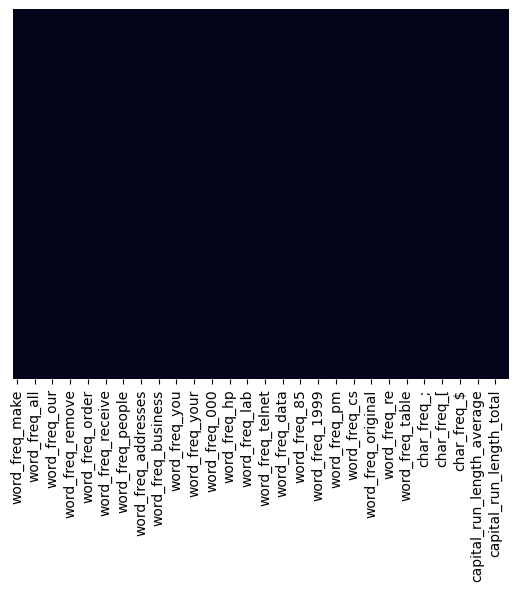

In [5]:
sns.heatmap(mail.isnull(), yticklabels=False, cbar=False)

Пропусков не обнаружено.

### Кодирование категорий

Не требуется, т.к. все признаки выражены числовыми значениями.

### Нормализация

In [6]:
scaler = StandardScaler()
a = mail
a = a.drop('capital_run_length_average', axis = 1)
a = a.drop('capital_run_length_longest', axis = 1)
a = a.drop('capital_run_length_total', axis = 1)
a = a.drop('spam', axis = 1)
b = pd.DataFrame()
b['capital_run_length_average'] = mail['capital_run_length_average']
b['capital_run_length_longest'] = mail['capital_run_length_longest']
b['capital_run_length_total'] = mail['capital_run_length_total']
b.describe()
mail_st = scaler.fit_transform(b)
mail_st = pd.DataFrame(mail_st)
mail_st = pd.concat([a, mail_st], axis=1)
mail_st['spam'] = mail['spam']
mail_st.rename(columns={0: 'capital_run_length_average', 1: 'capital_run_length_longest', 2:'capital_run_length_total'}, inplace=True)
mail_st.head()
mail_st.describe()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,spam
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4.601000e+03,4.601000e+03,4.601000e+03,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,4.324103e-17,1.235458e-17,2.470916e-17,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,1.000109e+00,1.000109e+00,1.000109e+00,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.321161e-01,-2.625994e-01,-4.656073e-01,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-1.135824e-01,-2.369413e-01,-4.095278e-01,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,-9.189671e-02,-1.907567e-01,-3.105639e-01,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,-4.682327e-02,-4.707129e-02,-2.851691e-02,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,3.458704e+01,5.099205e+01,2.566085e+01,1.000000


### Создание новых признаков

Не требуется.

## 4. EDA

<Axes: xlabel='spam', ylabel='count'>

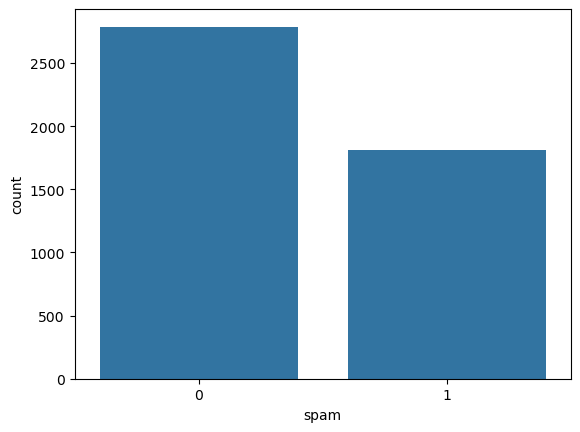

In [7]:
sns.countplot(x = 'spam', data = mail_st)

Спама почти вполовину меньше обычных писем.

<Axes: xlabel='capital_run_length_total', ylabel='Count'>

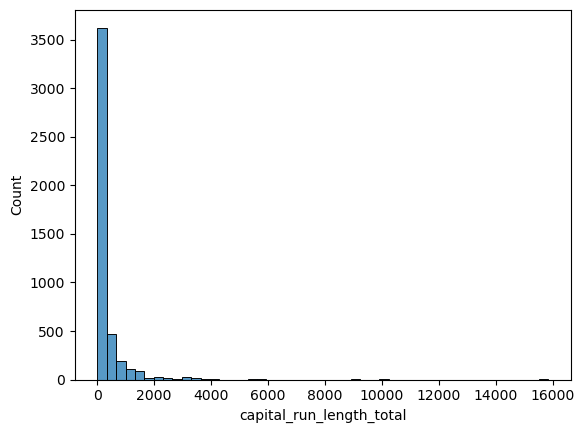

In [12]:
sns.histplot(data = mail, x = 'capital_run_length_total', bins = 48)

Большинство писем не содержат длинных последовательностей заглавных букв.

<Axes: xlabel='capital_run_length_average', ylabel='Count'>

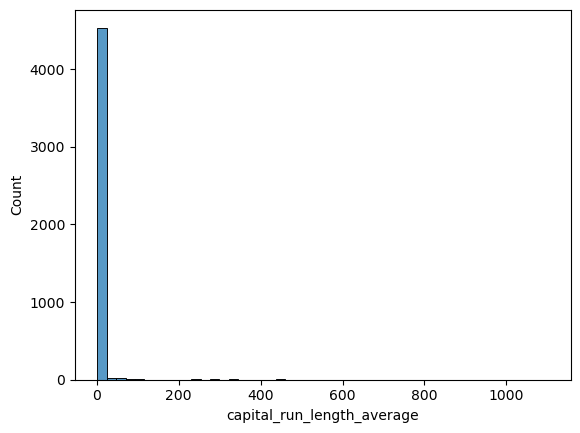

In [16]:
sns.histplot(data = mail, x = 'capital_run_length_average', bins = 48)

<Axes: xlabel='capital_run_length_longest', ylabel='Count'>

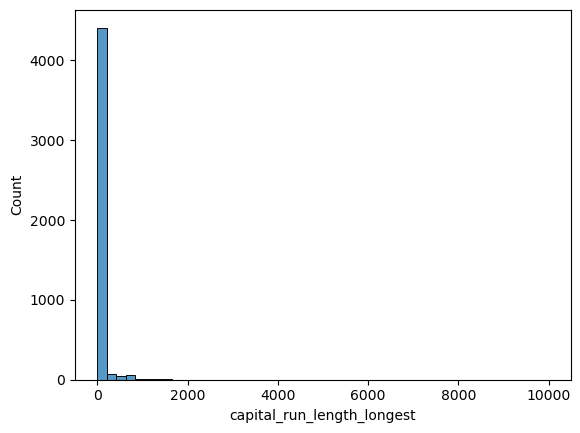

In [17]:
sns.histplot(data = mail, x = 'capital_run_length_longest', bins = 48)

<Axes: >

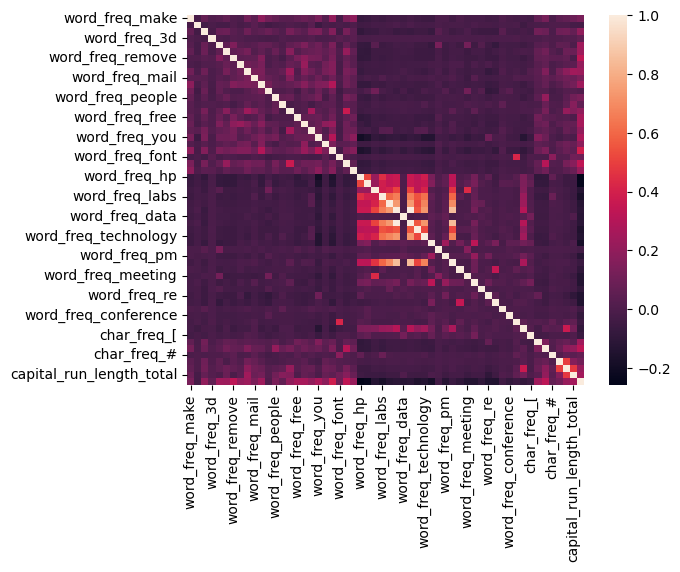

In [15]:
corr = mail.corr(numeric_only=True)
sns.heatmap(corr)

Слова из научной сферы чаще употребляются вместе.

## 5. Моделирование

Разделение данных на тренировочные и тестовые.

In [34]:
X = mail_st.drop('spam', axis = 1)
y = mail_st['spam']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(X,y, random_state = 42, test_size = 0.3, shuffle = True)

Логистическая регрессия.

In [43]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)
y_pred_lr = model_lr.predict(X_test)
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           0       0.91      0.95      0.93       804
           1       0.93      0.87      0.90       577

    accuracy                           0.92      1381
   macro avg       0.92      0.91      0.91      1381
weighted avg       0.92      0.92      0.91      1381



К ближайших соседей.

In [44]:
model_knn = KNeighborsClassifier(n_neighbors=3)
model_knn.fit(X_train, y_train)
y_pred_knn = model_knn.predict(X_test)
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.91      0.92      0.92       804
           1       0.89      0.87      0.88       577

    accuracy                           0.90      1381
   macro avg       0.90      0.90      0.90      1381
weighted avg       0.90      0.90      0.90      1381



Деревья решений.

In [45]:
model_tree = DecisionTreeClassifier(max_depth = 5)
model_tree.fit(X_train, y_train)
y_pred_tree = model_tree.predict(X_test)
print(classification_report(y_test, y_pred_tree))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92       804
           1       0.91      0.84      0.87       577

    accuracy                           0.90      1381
   macro avg       0.90      0.89      0.89      1381
weighted avg       0.90      0.90      0.90      1381



Случайный лес.

In [46]:
model_f = RandomForestClassifier(n_estimators = 100, max_depth = 5, random_state = 42)
model_f.fit(X_train, y_train)
y_pred_f = model_f.predict(X_test)
print(classification_report(y_test, y_pred_f))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       804
           1       0.96      0.85      0.90       577

    accuracy                           0.92      1381
   macro avg       0.93      0.91      0.92      1381
weighted avg       0.93      0.92      0.92      1381



Ансамблиевый.

In [56]:
model_ans = StackingClassifier(estimators = [('lr', LogisticRegression(random_state = 42)), ('dt', DecisionTreeClassifier(random_state = 42))
                               , ('rf', RandomForestClassifier(random_state = 42))], final_estimator = KNeighborsClassifier())
model_ans.fit(X_train, y_train)
y_pred_ans = model_ans.predict(X_test)
print(classification_report(y_test, y_pred_ans))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       804
           1       0.95      0.93      0.94       577

    accuracy                           0.95      1381
   macro avg       0.95      0.95      0.95      1381
weighted avg       0.95      0.95      0.95      1381



## 6. Оценка качества

In [61]:
models = pd.DataFrame([['logistic regression', accuracy_score(y_test, y_pred_lr)],
                      ['K-neighbours', accuracy_score(y_test, y_pred_knn)],
                      ['Decision tree', accuracy_score(y_test, y_pred_tree)],
                      ['Random forest', accuracy_score(y_test, y_pred_f)],
                      ['Ансамбль', accuracy_score(y_test, y_pred_ans)]])
models.rename(columns={0:'Модель', 1:'Accuracy'}, inplace=True)
models.head()

,Модель,Accuracy
0,logistic regression,0.915279
1,K-neighbours,0.901521
2,Decision tree,0.898624
3,Random forest,0.924692
4,Ансамбль,0.950036


## 7. Подбор гиперпараметров 

In [70]:
param_grid = {
    'stack_method' : ['predict_proba', 'predict'],
    'passthrough' : [False, True],
    'verbose' : [0, 1],
}
grid_search = GridSearchCV(estimator = model_ans, param_grid = param_grid, cv = 5, n_jobs = -1)
grid_search.fit(X_train, y_train)
print("Лучшие гиперпараметры: ", grid_search.best_params_)

Лучшие гиперпараметры:  {'passthrough': False, 'stack_method': 'predict', 'verbose': 0}


In [71]:
model_hp = grid_search
y_pred_hp = model_hp.predict(X_test)
print(classification_report(y_test, y_pred_hp))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96       804
           1       0.96      0.92      0.94       577

    accuracy                           0.95      1381
   macro avg       0.95      0.95      0.95      1381
weighted avg       0.95      0.95      0.95      1381



## 8. Интерпретация

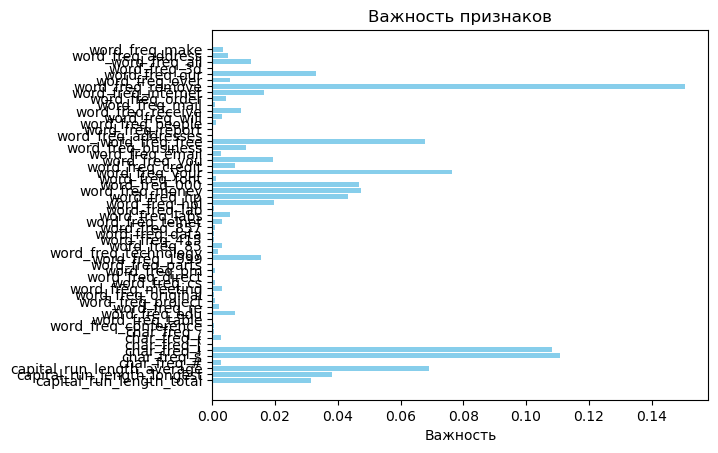

                       Feature  Gini Importance
6             word_freq_remove         0.150567
50                 char_freq_$         0.110788
49                 char_freq_!         0.108232
20              word_freq_your         0.076416
52  capital_run_length_average         0.069003
15              word_freq_free         0.067921
23             word_freq_money         0.047279
22               word_freq_000         0.046663
24                word_freq_hp         0.043160
53  capital_run_length_longest         0.038206
4                word_freq_our         0.033032
54    capital_run_length_total         0.031594
25               word_freq_hpl         0.019626
18               word_freq_you         0.019311
7           word_freq_internet         0.016586
34              word_freq_1999         0.015578
2                word_freq_all         0.012260
16          word_freq_business         0.010616
10           word_freq_receive         0.009034
19            word_freq_credit         0

In [90]:
col = list(X.columns)
importances = model_f.feature_importances_
feature_imp_df = pd.DataFrame({'Feature': col, 'Gini Importance': importances}).sort_values(
    'Gini Importance', ascending=False)
plt.barh(col, importances, color='skyblue')
plt.xlabel('Важность')
plt.title('Важность признаков')
plt.gca().invert_yaxis()
plt.show()
print(feature_imp_df)

## 9. Проверка гипотез

Слово "remove", а также символы '$' и '!' часто являются признаками спама.

## 10. Сохранение модели

In [92]:
pickle.dump(model_hp, open('spamoficator', 'wb'))